# OpenET vs NLDAS Noah ET Harmonization — Iowa 2019–2023

Computes the monthly delta between OpenET (actual ET including irrigation)
and NLDAS Noah ET (modeled ET without irrigation), masked to agricultural
pixels using the USDA Cropland Data Layer (CDL), to isolate the human
contribution to evapotranspiration in Iowa.

**Delta = OpenET − NLDAS_Noah_ET** (agricultural pixels only)
- Positive values → more ET than the land surface model predicts → likely irrigation
- Negative values → less ET than expected → drought, crop stress, or fallow land

**Data sources:**
- OpenET: `data/raw/OpenET/OpenET_Iowa_YYYYMM.tif` (mm/month, EPSG:4326, 0.125°)
- NLDAS Noah: `data/raw/NLDAS_Noah/NLDAS_NOAH0125_M.AYYYYMM.020.nc` — `Evap` (mm/month, EPSG:4326, 0.125°)
- CDL: `data/raw/Cornbelt_annual_CDL/Cornbelt_annual_CDL_cropland_YYYY-01.tif` (EPSG:4326, ~0.0045°)

**Pipeline:**
1. Resample annual CDL to NLDAS 0.125° grid → cropland fraction per pixel
2. Build binary cropland mask (fraction > threshold)
3. For each month: load NLDAS + OpenET, align grids, apply mask, compute delta
4. Save masked delta GeoTIFFs and summary statistics

**Output:** `data/processed/ET_delta/ET_delta_YYYYMM_Iowa_cropland.tif`

In [1]:
import sys, os
print(f'Python: {sys.executable}')

import matplotlib
# matplotlib.use('Agg') is only needed on headless HPC nodes.
# In VS Code, omit it so plots render interactively.
_is_hpc = os.environ.get('SLURM_JOB_ID') or os.environ.get('SIF_ROOT')
if _is_hpc:
    matplotlib.use('Agg')

import xarray as xr
import rioxarray as rxr
import rasterio
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print(f'matplotlib backend: {matplotlib.get_backend()}')
print('Libraries loaded successfully!')

Python: /home/pielab-sandbox-jcoldiron/.venv/bin/python
matplotlib backend: module://matplotlib_inline.backend_inline
Libraries loaded successfully!


## 1. Paths and Configuration

In [2]:
# HPC-friendly project root.
# Set SIF_ROOT in your SLURM script (export SIF_ROOT=/path/to/SIF),
# or run from the project root so the relative fallback works.
_root_env = os.environ.get('SIF_ROOT')
project_root = Path(_root_env) if _root_env else Path('../../..').resolve()
print(f'Project root: {project_root}')

nldas_dir   = project_root / 'data' / 'raw' / 'NLDAS_Noah'
openet_dir  = project_root / 'data' / 'raw' / 'OpenET'
cdl_dir     = project_root / 'data' / 'raw' / 'Cornbelt_annual_CDL'
output_dir  = project_root / 'data' / 'processed' / 'ET_delta'
mask_dir    = project_root / 'data' / 'processed' / 'cropland_masks'
figures_dir = project_root / 'figures' / 'et_delta'
iowa_boundary = project_root / 'data' / 'aoi' / 'iowa.geojson'

output_dir.mkdir(parents=True, exist_ok=True)
mask_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

YEARS  = list(range(2019, 2024))
MONTHS = list(range(1, 13))

# CDL codes < 100 are crops; >= 100 are non-agricultural (water, developed, forest, etc.)
CROPLAND_MAX_CODE = 100

# Minimum cropland fraction within an NLDAS pixel to be included in analysis
CROPLAND_FRACTION_THRESHOLD = 0.5

# Verify input files
nldas_files  = sorted(nldas_dir.glob('NLDAS_NOAH0125_M.A*.nc'))
openet_files = sorted(openet_dir.glob('OpenET_Iowa_*.tif'))
cdl_files    = sorted(cdl_dir.glob('Cornbelt_annual_CDL_cropland_*.tif'))

print(f'NLDAS Noah files:  {len(nldas_files)} (expected 60)')
print(f'OpenET files:      {len(openet_files)} (expected 60)')
print(f'CDL files:         {len(cdl_files)}')
print(f'Output directory:  {output_dir}')
print(f'Mask directory:    {mask_dir}')

Project root: /home/pielab-sandbox-jcoldiron/SIF-Analysis
NLDAS Noah files:  60 (expected 60)
OpenET files:      60 (expected 60)
CDL files:         6
Output directory:  /home/pielab-sandbox-jcoldiron/SIF-Analysis/data/processed/ET_delta
Mask directory:    /home/pielab-sandbox-jcoldiron/SIF-Analysis/data/processed/cropland_masks


## 2. Verify Spatial Alignment

Confirm NLDAS, OpenET, and CDL are all in EPSG:4326 and check resolutions.

In [3]:
iowa_gdf = gpd.read_file(iowa_boundary)

# NLDAS grid
ds_nldas = xr.open_dataset(nldas_files[0])
print('NLDAS Noah:')
print(f'  lon: {float(ds_nldas.lon[0]):.4f} to {float(ds_nldas.lon[-1]):.4f}, step={float(ds_nldas.lon[1]-ds_nldas.lon[0]):.4f}°')
print(f'  lat: {float(ds_nldas.lat[0]):.4f} to {float(ds_nldas.lat[-1]):.4f}, step={float(ds_nldas.lat[1]-ds_nldas.lat[0]):.4f}°')
ds_nldas.close()

# OpenET grid
with rasterio.open(openet_files[0]) as src:
    openet_transform = src.transform
    openet_crs = src.crs
    openet_shape = (src.height, src.width)
    print(f'\nOpenET:')
    print(f'  CRS: {openet_crs}')
    print(f'  Origin: ({openet_transform.c:.4f}, {openet_transform.f:.4f})')
    print(f'  Resolution: {openet_transform.a:.4f}°')
    print(f'  Shape: {openet_shape[0]} x {openet_shape[1]}')

# CDL
with rasterio.open(cdl_files[0]) as src:
    print(f'\nCDL:')
    print(f'  CRS: {src.crs}')
    print(f'  Resolution: {src.res[0]:.6f}° (~{src.res[0]*111:.1f} km)')
    print(f'  Shape: {src.height} x {src.width}')
    print(f'  → Will be resampled to 0.125° to match NLDAS/OpenET grid')

NLDAS Noah:
  lon: -124.9375 to -67.0625, step=0.1250°
  lat: 25.0625 to 52.9375, step=0.1250°

OpenET:
  CRS: EPSG:4326
  Origin: (-96.7500, 43.6250)
  Resolution: 0.1250°
  Shape: 26 x 53

CDL:
  CRS: EPSG:4326
  Resolution: 0.004492° (~0.5 km)
  Shape: 697 x 1448
  → Will be resampled to 0.125° to match NLDAS/OpenET grid


## 2.5. OpenET and NLDAS Raw Data Coverage Check

Spot-check 10 evenly-spaced tiles from each dataset before processing.

- **OpenET:** confirm full Iowa coverage, no tiling gaps, spatial variation visible
- **NLDAS:** confirm correct north-up orientation (lats are stored S→N ascending; we flip before display)

A tight percentile colorscale (p2–p98) is used so small spatial variations are distinguishable.

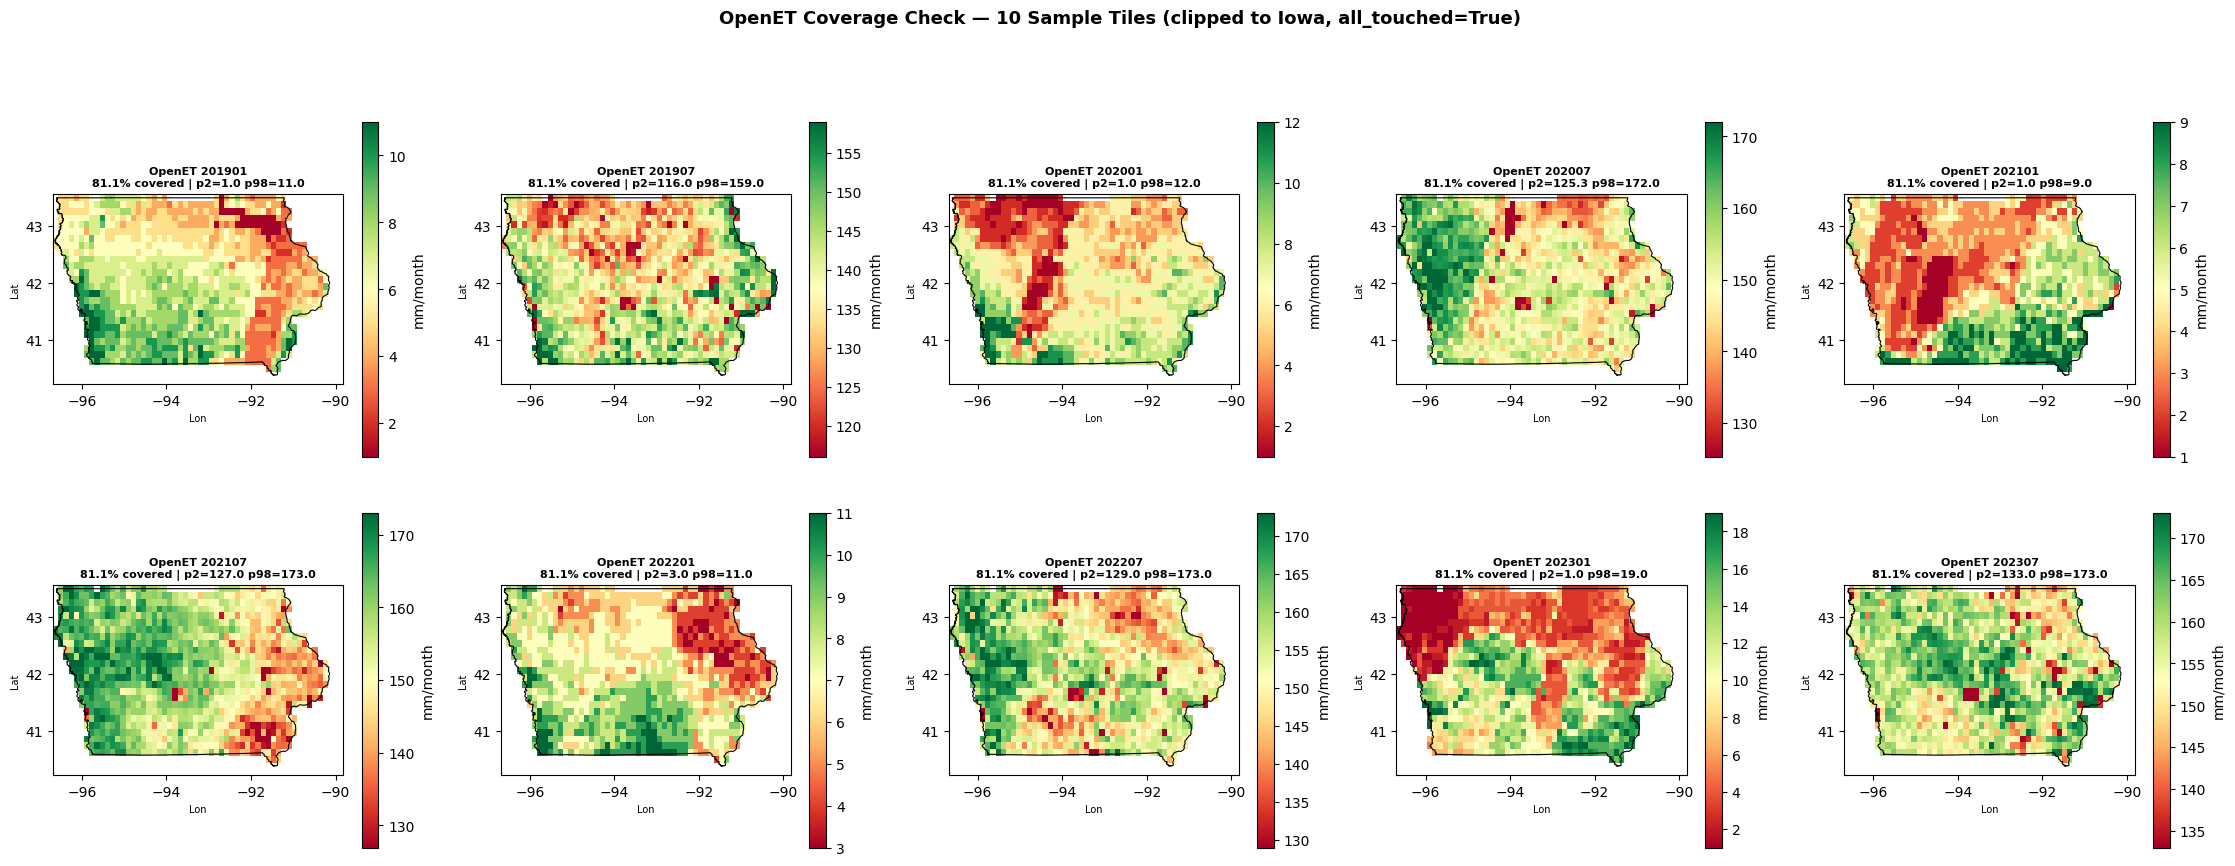

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/et_delta/openet_coverage_check.png


In [4]:
# ── OpenET: 10 tile coverage check ───────────────────────────────────────────
if len(openet_files) == 0:
    print('WARNING: No OpenET files found — skipping coverage check.')
else:
    step   = max(1, len(openet_files) // 10)
    sample = openet_files[::step][:10]

    ncols = 5
    nrows = (len(sample) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.5))
    axes = np.array(axes).flatten()

    for i, fpath in enumerate(sample):
        ax = axes[i]

        # Clip to Iowa with all_touched=True so border pixels are included
        da = rxr.open_rasterio(fpath, masked=True).squeeze()
        da_iowa = da.rio.clip(iowa_gdf.geometry, iowa_gdf.crs,
                              all_touched=True, drop=True)
        arr = da_iowa.values.astype(float)
        arr[arr < -9000] = np.nan

        valid = arr[~np.isnan(arr)]
        if len(valid) == 0:
            ax.set_title(f'{fpath.stem}\nNO VALID DATA', color='red')
            ax.set_visible(True)
            continue

        # Tight percentile range highlights small spatial variations
        vmin, vmax = np.nanpercentile(valid, [2, 98])
        # Guard against flat months (e.g. winter, all near zero)
        if vmax - vmin < 1:
            vmin, vmax = vmin - 0.5, vmax + 0.5

        extent = [float(da_iowa.x.min()), float(da_iowa.x.max()),
                  float(da_iowa.y.min()), float(da_iowa.y.max())]

        im = ax.imshow(arr, extent=extent, origin='upper',
                       cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')
        iowa_gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
        plt.colorbar(im, ax=ax, shrink=0.75, label='mm/month')

        yyyymm   = fpath.stem.replace('OpenET_Iowa_', '')
        n_nan    = np.isnan(arr).sum()
        coverage = 100 * (1 - n_nan / arr.size)
        ax.set_title(f'OpenET {yyyymm}\n{coverage:.1f}% covered | p2={vmin:.1f} p98={vmax:.1f}',
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Lon', fontsize=7)
        ax.set_ylabel('Lat', fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('OpenET Coverage Check — 10 Sample Tiles (clipped to Iowa, all_touched=True)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(figures_dir / 'openet_coverage_check.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_dir}/openet_coverage_check.png')

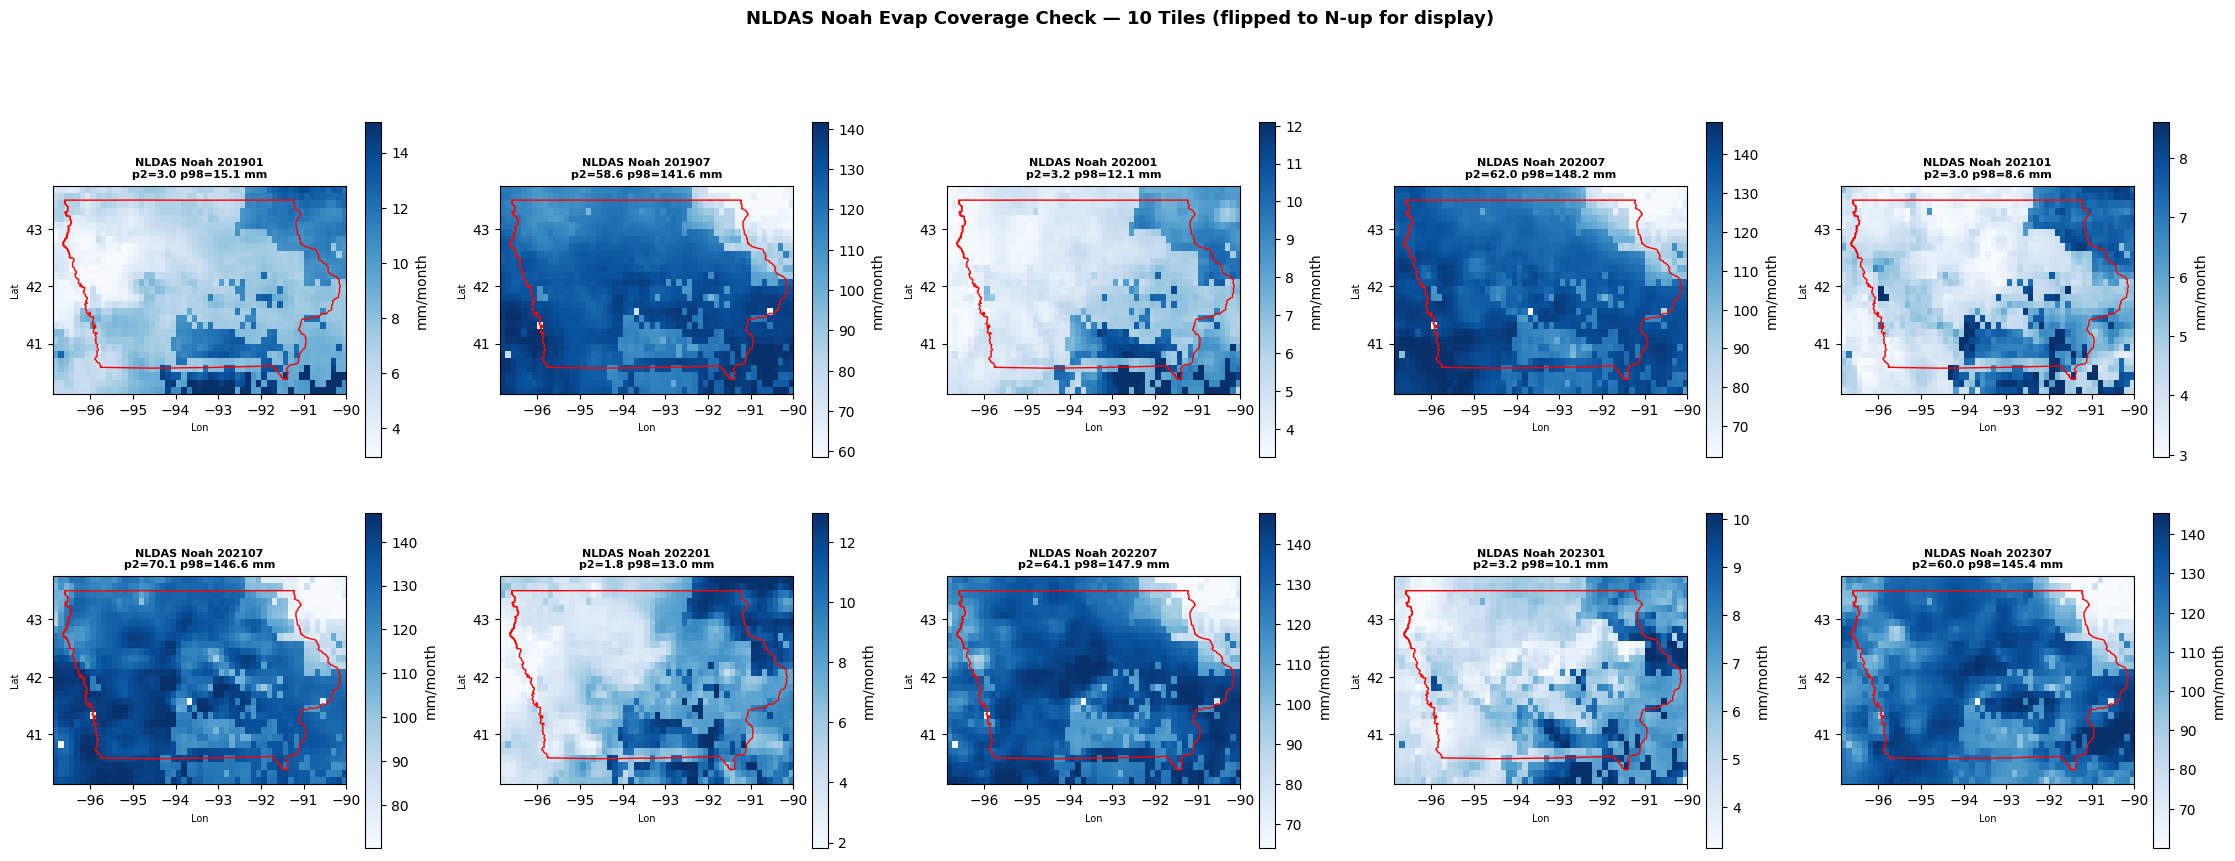

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/et_delta/nldas_coverage_check.png


In [5]:
# ── NLDAS: 10 tile coverage check with orientation fix ───────────────────────
# NLDAS stores latitudes in ascending order (south→north, lat[0]=25°).
# Displayed with origin='upper' this puts south at the top — upside down.
# We flip the array vertically before plotting so north is up.

if len(nldas_files) == 0:
    print('WARNING: No NLDAS files found — skipping coverage check.')
else:
    step   = max(1, len(nldas_files) // 10)
    sample = nldas_files[::step][:10]

    iowa_bb = iowa_gdf.total_bounds  # [minx, miny, maxx, maxy]

    ncols = 5
    nrows = (len(sample) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4.5, nrows * 4.5))
    axes = np.array(axes).flatten()

    for i, fpath in enumerate(sample):
        ax = axes[i]
        ds  = xr.open_dataset(fpath)
        et  = ds['Evap'].squeeze()

        lats = et.lat.values   # ascending: 25.06 → 52.94
        lons = et.lon.values
        arr  = et.values.astype(float)
        arr[arr <= -9000] = np.nan
        ds.close()

        # Subset to Iowa bounding box (with small buffer)
        lat_mask = (lats >= iowa_bb[1] - 0.2) & (lats <= iowa_bb[3] + 0.2)
        lon_mask = (lons >= iowa_bb[0] - 0.2) & (lons <= iowa_bb[2] + 0.2)
        arr_iowa  = arr[np.ix_(lat_mask, lon_mask)]
        lats_iowa = lats[lat_mask]
        lons_iowa = lons[lon_mask]

        # Flip to north-up: reverse row order so lat[0] (south) is at the bottom
        arr_iowa  = arr_iowa[::-1, :]
        lats_iowa = lats_iowa[::-1]

        valid = arr_iowa[~np.isnan(arr_iowa)]
        if len(valid) == 0:
            ax.set_title(f'{fpath.stem}\nNO VALID DATA', color='red')
            continue

        vmin, vmax = np.nanpercentile(valid, [2, 98])
        if vmax - vmin < 0.5:
            vmin, vmax = vmin - 0.25, vmax + 0.25

        # extent for imshow: [left, right, bottom, top]
        # lats_iowa[0] is now north (after flip), lats_iowa[-1] is south
        extent = [lons_iowa.min() - 0.0625, lons_iowa.max() + 0.0625,
                  lats_iowa[-1] - 0.0625,   lats_iowa[0]  + 0.0625]

        im = ax.imshow(arr_iowa, extent=extent, origin='upper',
                       cmap='Blues', vmin=vmin, vmax=vmax, aspect='auto')
        iowa_gdf.boundary.plot(ax=ax, color='red', linewidth=1.0)
        plt.colorbar(im, ax=ax, shrink=0.75, label='mm/month')

        yyyymm = fpath.name.split('.A')[1][:6] if '.A' in fpath.name else fpath.stem
        ax.set_title(f'NLDAS Noah {yyyymm}\np2={vmin:.1f} p98={vmax:.1f} mm',
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Lon', fontsize=7)
        ax.set_ylabel('Lat', fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('NLDAS Noah Evap Coverage Check — 10 Tiles (flipped to N-up for display)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(figures_dir / 'nldas_coverage_check.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Saved: {figures_dir}/nldas_coverage_check.png')

## 3. Define NLDAS Reference Grid and Build Annual Cropland Masks

NLDAS is the coarser reference grid (0.125°). OpenET will be resampled onto it.
CDL (~0.0045°) is also resampled to NLDAS resolution.

For each year:
1. Load CDL (crop codes, EPSG:4326, ~0.0045°)
2. Create binary cropland layer (code < 100 = crop)
3. Resample to NLDAS 0.125° grid using **average** resampling → cropland fraction per pixel
4. Threshold at `CROPLAND_FRACTION_THRESHOLD` to create final binary mask

In [6]:
import rasterio.transform

def build_cropland_mask(cdl_path, target_transform, target_shape, target_crs='EPSG:4326',
                         threshold=0.5, cropland_max_code=100):
    """
    Resample CDL to NLDAS grid and return a boolean cropland mask.

    Returns
    -------
    mask : np.ndarray (bool), shape = target_shape
        True where the NLDAS pixel is >= threshold cropland fraction.
    crop_fraction : np.ndarray (float), shape = target_shape
        Cropland fraction per NLDAS pixel (0–1).
    """
    with rasterio.open(cdl_path) as src:
        cdl_data = src.read(1).astype(np.float32)
        cdl_transform = src.transform
        cdl_crs = src.crs

    # Binary: 1 = cropland (code < 100), 0 = non-crop
    binary = np.where((cdl_data > 0) & (cdl_data < cropland_max_code), 1.0, 0.0)
    binary[cdl_data == 0] = np.nan  # true nodata → NaN so it doesn't dilute the fraction

    # Resample to NLDAS grid using average → gives cropland fraction per pixel
    crop_fraction = np.empty(target_shape, dtype=np.float32)
    reproject(
        source=binary,
        destination=crop_fraction,
        src_transform=cdl_transform,
        src_crs=cdl_crs,
        src_nodata=np.nan,
        dst_transform=target_transform,
        dst_crs=target_crs,
        resampling=Resampling.average
    )

    mask = crop_fraction >= threshold
    return mask, crop_fraction


# ── Get NLDAS reference grid (transform + shape) ──────────────────────────
ds_ref = xr.open_dataset(nldas_files[0])
nldas_lons = ds_ref.lon.values
nldas_lats = ds_ref.lat.values
ds_ref.close()

nldas_res = 0.125
nldas_transform = rasterio.transform.from_origin(
    west  = nldas_lons[0]  - nldas_res / 2,
    north = nldas_lats[-1] + nldas_res / 2,
    xsize = nldas_res,
    ysize = nldas_res
)
nldas_shape = (len(nldas_lats), len(nldas_lons))

print(f'NLDAS reference grid:')
print(f'  Shape: {nldas_shape[0]} rows x {nldas_shape[1]} cols')
print(f'  Transform: {nldas_transform}')

# ── Build or load annual cropland masks ───────────────────────────────────
# Fractions are cached as GeoTIFFs in mask_dir so CDL resampling only runs once.
cropland_masks    = {}
cropland_fraction = {}

for year in YEARS:
    frac_path = mask_dir / f'cropland_fraction_{year}_nldas.tif'

    if frac_path.exists():
        # Load from cached GeoTIFF
        with rasterio.open(frac_path) as src:
            frac = src.read(1)
        mask = frac >= CROPLAND_FRACTION_THRESHOLD
        source_label = 'cache'
    else:
        # Build from CDL and save
        cdl_path = cdl_dir / f'Cornbelt_annual_CDL_cropland_{year}-01.tif'
        if not cdl_path.exists():
            print(f'  WARNING: CDL not found for {year}')
            continue
        mask, frac = build_cropland_mask(
            cdl_path, nldas_transform, nldas_shape,
            threshold=CROPLAND_FRACTION_THRESHOLD
        )
        # Save cropland fraction — mask can always be reconstructed via threshold
        with rasterio.open(
            frac_path, 'w', driver='GTiff',
            height=nldas_shape[0], width=nldas_shape[1],
            count=1, dtype=np.float32,
            crs='EPSG:4326', transform=nldas_transform
        ) as dst:
            dst.write(frac, 1)
        source_label = 'built + saved'

    cropland_masks[year]    = mask
    cropland_fraction[year] = frac
    pct = mask.sum() / mask.size * 100
    print(f'  {year} [{source_label}]: {mask.sum()} cropland pixels ({pct:.1f}%)  '
          f'| mean cropland fraction = {np.nanmean(frac):.2f}')

print('\nCropland masks ready.')

NLDAS reference grid:
  Shape: 224 rows x 464 cols
  Transform: | 0.12, 0.00,-125.00|
| 0.00,-0.12, 53.00|
| 0.00, 0.00, 1.00|
  2019 [cache]: 788 cropland pixels (0.8%)  | mean cropland fraction = 0.53
  2020 [cache]: 794 cropland pixels (0.8%)  | mean cropland fraction = 0.53
  2021 [cache]: 789 cropland pixels (0.8%)  | mean cropland fraction = 0.53
  2022 [cache]: 769 cropland pixels (0.7%)  | mean cropland fraction = 0.52
  2023 [cache]: 776 cropland pixels (0.7%)  | mean cropland fraction = 0.52

Cropland masks ready.


## 4. Visualize Cropland Masks

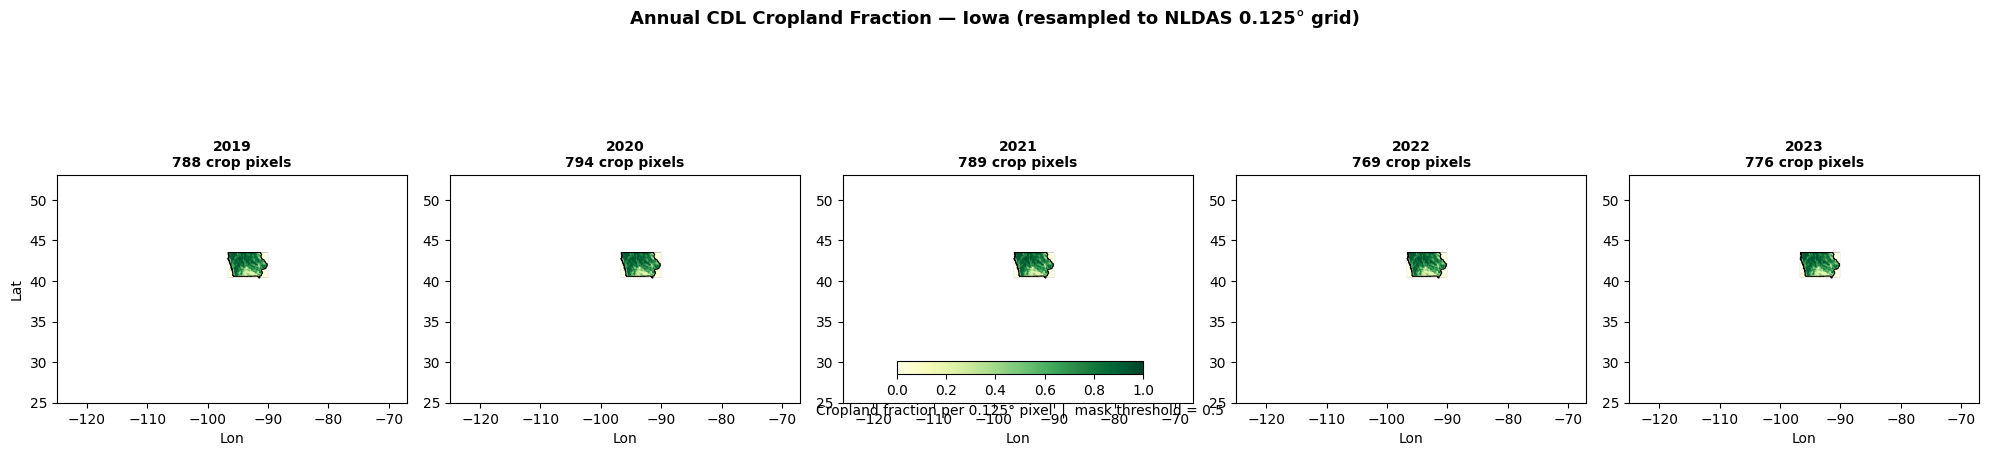

In [7]:
fig, axes = plt.subplots(1, len(YEARS), figsize=(20, 4))

for ax, year in zip(axes, YEARS):
    if year not in cropland_fraction:
        ax.set_visible(False)
        continue

    frac = cropland_fraction[year]

    # The mask is north-up (built via rasterio north-up transform), so origin='upper'
    # Extent: [west, east, south, north] in degrees
    west  = nldas_transform.c
    north = nldas_transform.f
    east  = west  + nldas_transform.a * nldas_shape[1]
    south = north + nldas_transform.e * nldas_shape[0]   # e is negative

    im = ax.imshow(
        frac,
        extent=[west, east, south, north],
        origin='upper', cmap='YlGn', vmin=0, vmax=1, aspect='auto'
    )
    iowa_gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
    n = cropland_masks[year].sum()
    ax.set_title(f'{year}\n{n} crop pixels', fontsize=10, fontweight='bold')
    ax.set_xlabel('Lon')

axes[0].set_ylabel('Lat')
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.04, pad=0.2)
cbar.set_label(f'Cropland fraction per 0.125° pixel  |  mask threshold = {CROPLAND_FRACTION_THRESHOLD}')
plt.suptitle('Annual CDL Cropland Fraction — Iowa (resampled to NLDAS 0.125° grid)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figures_dir / 'cropland_masks.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Process All 60 Months — Compute Masked Delta

In [8]:
records     = []
delta_grids = {}  # (year, month) → masked delta DataArray
skipped     = []

for year in YEARS:
    mask = cropland_masks.get(year)
    if mask is None:
        print(f'  SKIP {year}: no cropland mask')
        skipped.extend([f'{year}{m:02d}' for m in MONTHS])
        continue

    for month in MONTHS:
        yyyymm = f'{year}{month:02d}'

        nldas_path  = nldas_dir  / f'NLDAS_NOAH0125_M.A{yyyymm}.020.nc'
        openet_path = openet_dir / f'OpenET_Iowa_{yyyymm}.tif'
        out_path    = output_dir / f'ET_delta_{yyyymm}_Iowa_cropland.tif'

        if not nldas_path.exists() or not openet_path.exists():
            skipped.append(yyyymm)
            print(f'  SKIP {yyyymm}: missing file(s)')
            continue

        # ── Load NLDAS Noah Evap ──────────────────────────────────────────
        ds = xr.open_dataset(nldas_path)
        nldas_et = ds['Evap'].squeeze()   # mm/month

        # NLDAS stores latitudes ascending (south→north, lat[0]=25°).
        # Flip to north-up so row-0 = northernmost pixel — consistent with
        # rasterio convention and the north-up CDL cropland mask on disk.
        if float(nldas_et.lat[0]) < float(nldas_et.lat[-1]):
            nldas_et = nldas_et.isel(lat=slice(None, None, -1))

        nldas_et = nldas_et.rename({'lon': 'x', 'lat': 'y'})
        nldas_et = nldas_et.rio.write_crs('EPSG:4326')

        # Center-based clip: include only pixels whose center falls within Iowa.
        # all_touched=True pulled in edge cells whose centers are outside Iowa,
        # producing white NaN strips at top/bottom after cropland masking.
        nldas_iowa = nldas_et.rio.clip(iowa_gdf.geometry, iowa_gdf.crs,
                                        drop=True, all_touched=False)
        ds.close()

        # ── Load OpenET and align to NLDAS Iowa grid ─────────────────────
        openet_raw      = rxr.open_rasterio(openet_path, masked=True).squeeze()
        openet_resampled = openet_raw.rio.reproject_match(
            nldas_iowa, resampling=Resampling.average
        )

        # ── Compute raw delta ─────────────────────────────────────────────
        delta = openet_resampled.values - nldas_iowa.values   # mm/month

        # ── Extract cropland mask aligned to Iowa NLDAS grid ─────────────
        # The saved GeoTIFF is north-up (built with from_origin north-up transform).
        # reproject_match aligns it pixel-perfectly to nldas_iowa (also north-up).
        frac_da   = rxr.open_rasterio(
            mask_dir / f'cropland_fraction_{year}_nldas.tif', masked=True
        ).squeeze()
        frac_iowa = frac_da.rio.reproject_match(nldas_iowa, resampling=Resampling.nearest)
        iowa_mask = (frac_iowa.values >= CROPLAND_FRACTION_THRESHOLD) & \
                    ~np.isnan(frac_iowa.values)

        if iowa_mask.shape != delta.shape:
            raise ValueError(f'{yyyymm}: mask shape {iowa_mask.shape} != delta shape {delta.shape}')

        # ── Apply cropland mask ───────────────────────────────────────────
        delta_masked = np.where(iowa_mask, delta, np.nan)

        # ── Save GeoTIFF (north-up, matching NLDAS Iowa grid) ─────────────
        delta_da = xr.DataArray(
            delta_masked,
            coords={'y': nldas_iowa.y, 'x': nldas_iowa.x},
            dims=['y', 'x']
        )
        delta_da = delta_da.rio.write_crs('EPSG:4326')
        delta_da.rio.to_raster(out_path)

        # ── Summary stats (cropland pixels only) ─────────────────────────
        valid_openet = openet_resampled.values[iowa_mask & ~np.isnan(openet_resampled.values)]
        valid_nldas  = nldas_iowa.values[iowa_mask & ~np.isnan(nldas_iowa.values)]
        valid_delta  = delta_masked[~np.isnan(delta_masked)]

        records.append({
            'year': year, 'month': month, 'yyyymm': yyyymm,
            'n_crop_pixels': int(iowa_mask.sum()),
            'openet_mean':   float(valid_openet.mean()) if len(valid_openet) else np.nan,
            'nldas_mean':    float(valid_nldas.mean())  if len(valid_nldas)  else np.nan,
            'delta_mean':    float(valid_delta.mean())  if len(valid_delta)  else np.nan,
            'delta_std':     float(valid_delta.std())   if len(valid_delta)  else np.nan,
            'delta_min':     float(valid_delta.min())   if len(valid_delta)  else np.nan,
            'delta_max':     float(valid_delta.max())   if len(valid_delta)  else np.nan,
        })
        delta_grids[(year, month)] = delta_da

        print(f'  {yyyymm}: OpenET={records[-1]["openet_mean"]:6.1f}  '
              f'NLDAS={records[-1]["nldas_mean"]:6.1f}  '
              f'Δ={records[-1]["delta_mean"]:+6.1f} mm/month  '
              f'[{records[-1]["n_crop_pixels"]} crop px]')

df = pd.DataFrame(records)
print(f'\nProcessed {len(df)} months, skipped {len(skipped)}')

  201901: OpenET=   6.0  NLDAS=   6.7  Δ=  -0.7 mm/month  [788 crop px]
  201902: OpenET=   4.9  NLDAS=   7.5  Δ=  -2.6 mm/month  [788 crop px]
  201903: OpenET=  22.8  NLDAS=  16.5  Δ=  +6.3 mm/month  [788 crop px]
  201904: OpenET=  44.5  NLDAS=  30.0  Δ= +14.6 mm/month  [788 crop px]
  201905: OpenET=  58.9  NLDAS=  54.9  Δ=  +4.0 mm/month  [788 crop px]
  201906: OpenET=  94.4  NLDAS=  85.2  Δ=  +9.2 mm/month  [788 crop px]
  201907: OpenET= 135.2  NLDAS= 124.3  Δ= +10.9 mm/month  [788 crop px]
  201908: OpenET= 109.2  NLDAS= 100.2  Δ=  +9.0 mm/month  [788 crop px]
  201909: OpenET=  72.9  NLDAS=  75.2  Δ=  -2.3 mm/month  [788 crop px]
  201910: OpenET=  31.5  NLDAS=  34.7  Δ=  -3.2 mm/month  [788 crop px]
  201911: OpenET=  13.9  NLDAS=   8.6  Δ=  +5.4 mm/month  [788 crop px]
  201912: OpenET=   7.3  NLDAS=   3.8  Δ=  +3.5 mm/month  [788 crop px]
  202001: OpenET=   5.4  NLDAS=   5.3  Δ=  +0.1 mm/month  [794 crop px]
  202002: OpenET=  13.4  NLDAS=   6.0  Δ=  +7.4 mm/month  [794 c

## 5.5 Diagnostic — Save & Visualize Cropland-Masked NLDAS and OpenET

Re-process each month to save the masked NLDAS and OpenET layers individually
(before differencing), then visualize 10 sample months side-by-side to confirm
the cropland mask is being applied correctly to both datasets.

In [9]:
# Output directories for masked individual layers
nldas_masked_dir  = project_root / 'data' / 'processed' / 'NLDAS_masked_cropland'
openet_masked_dir = project_root / 'data' / 'processed' / 'OpenET_masked_cropland'
nldas_masked_dir.mkdir(exist_ok=True)
openet_masked_dir.mkdir(exist_ok=True)

for year in YEARS:
    mask_yr = cropland_masks.get(year)
    if mask_yr is None:
        continue
    frac_da = rxr.open_rasterio(
        mask_dir / f'cropland_fraction_{year}_nldas.tif', masked=True
    ).squeeze()

    for month in MONTHS:
        yyyymm      = f'{year}{month:02d}'
        nldas_path  = nldas_dir  / f'NLDAS_NOAH0125_M.A{yyyymm}.020.nc'
        openet_path = openet_dir / f'OpenET_Iowa_{yyyymm}.tif'
        if not nldas_path.exists() or not openet_path.exists():
            continue

        # Load and align NLDAS (same pipeline as main loop)
        ds = xr.open_dataset(nldas_path)
        nldas_et = ds['Evap'].squeeze()
        if float(nldas_et.lat[0]) < float(nldas_et.lat[-1]):
            nldas_et = nldas_et.isel(lat=slice(None, None, -1))
        nldas_et   = nldas_et.rename({'lon': 'x', 'lat': 'y'}).rio.write_crs('EPSG:4326')
        nldas_iowa = nldas_et.rio.clip(iowa_gdf.geometry, iowa_gdf.crs,
                                        drop=True, all_touched=False)
        ds.close()

        # Load and align OpenET
        openet_raw     = rxr.open_rasterio(openet_path, masked=True).squeeze()
        openet_aligned = openet_raw.rio.reproject_match(nldas_iowa, resampling=Resampling.average)

        # Align cropland mask to Iowa grid
        frac_iowa = frac_da.rio.reproject_match(nldas_iowa, resampling=Resampling.nearest)
        iowa_mask = (frac_iowa.values >= CROPLAND_FRACTION_THRESHOLD) & ~np.isnan(frac_iowa.values)

        # Apply mask and save
        for arr, out_dir, prefix in [
            (nldas_iowa.values,     nldas_masked_dir,  'NLDAS'),
            (openet_aligned.values, openet_masked_dir, 'OpenET'),
        ]:
            masked = np.where(iowa_mask, arr, np.nan)
            da_out = xr.DataArray(masked, coords={'y': nldas_iowa.y, 'x': nldas_iowa.x}, dims=['y','x'])
            da_out.rio.write_crs('EPSG:4326').rio.to_raster(
                out_dir / f'{prefix}_Iowa_cropland_{yyyymm}.tif'
            )

        print(f'  {yyyymm}: saved', end='  ')

print(f'\nDone.\n  NLDAS masked → {nldas_masked_dir}\n  OpenET masked → {openet_masked_dir}')

  201901: saved    201902: saved    201903: saved    201904: saved    201905: saved    201906: saved    201907: saved    201908: saved    201909: saved    201910: saved    201911: saved    201912: saved    202001: saved    202002: saved    202003: saved    202004: saved    202005: saved    202006: saved    202007: saved    202008: saved    202009: saved    202010: saved    202011: saved    202012: saved    202101: saved    202102: saved    202103: saved    202104: saved    202105: saved    202106: saved    202107: saved    202108: saved    202109: saved    202110: saved    202111: saved    202112: saved    202201: saved    202202: saved    202203: saved    202204: saved    202205: saved    202206: saved    202207: saved    202208: saved    202209: saved    202210: saved    202211: saved    202212: saved    202301: saved    202302: saved    202303: saved    202304: saved    202305: saved    202306: saved    202307: saved    202308: saved    202309: saved    202310: saved    202311: save

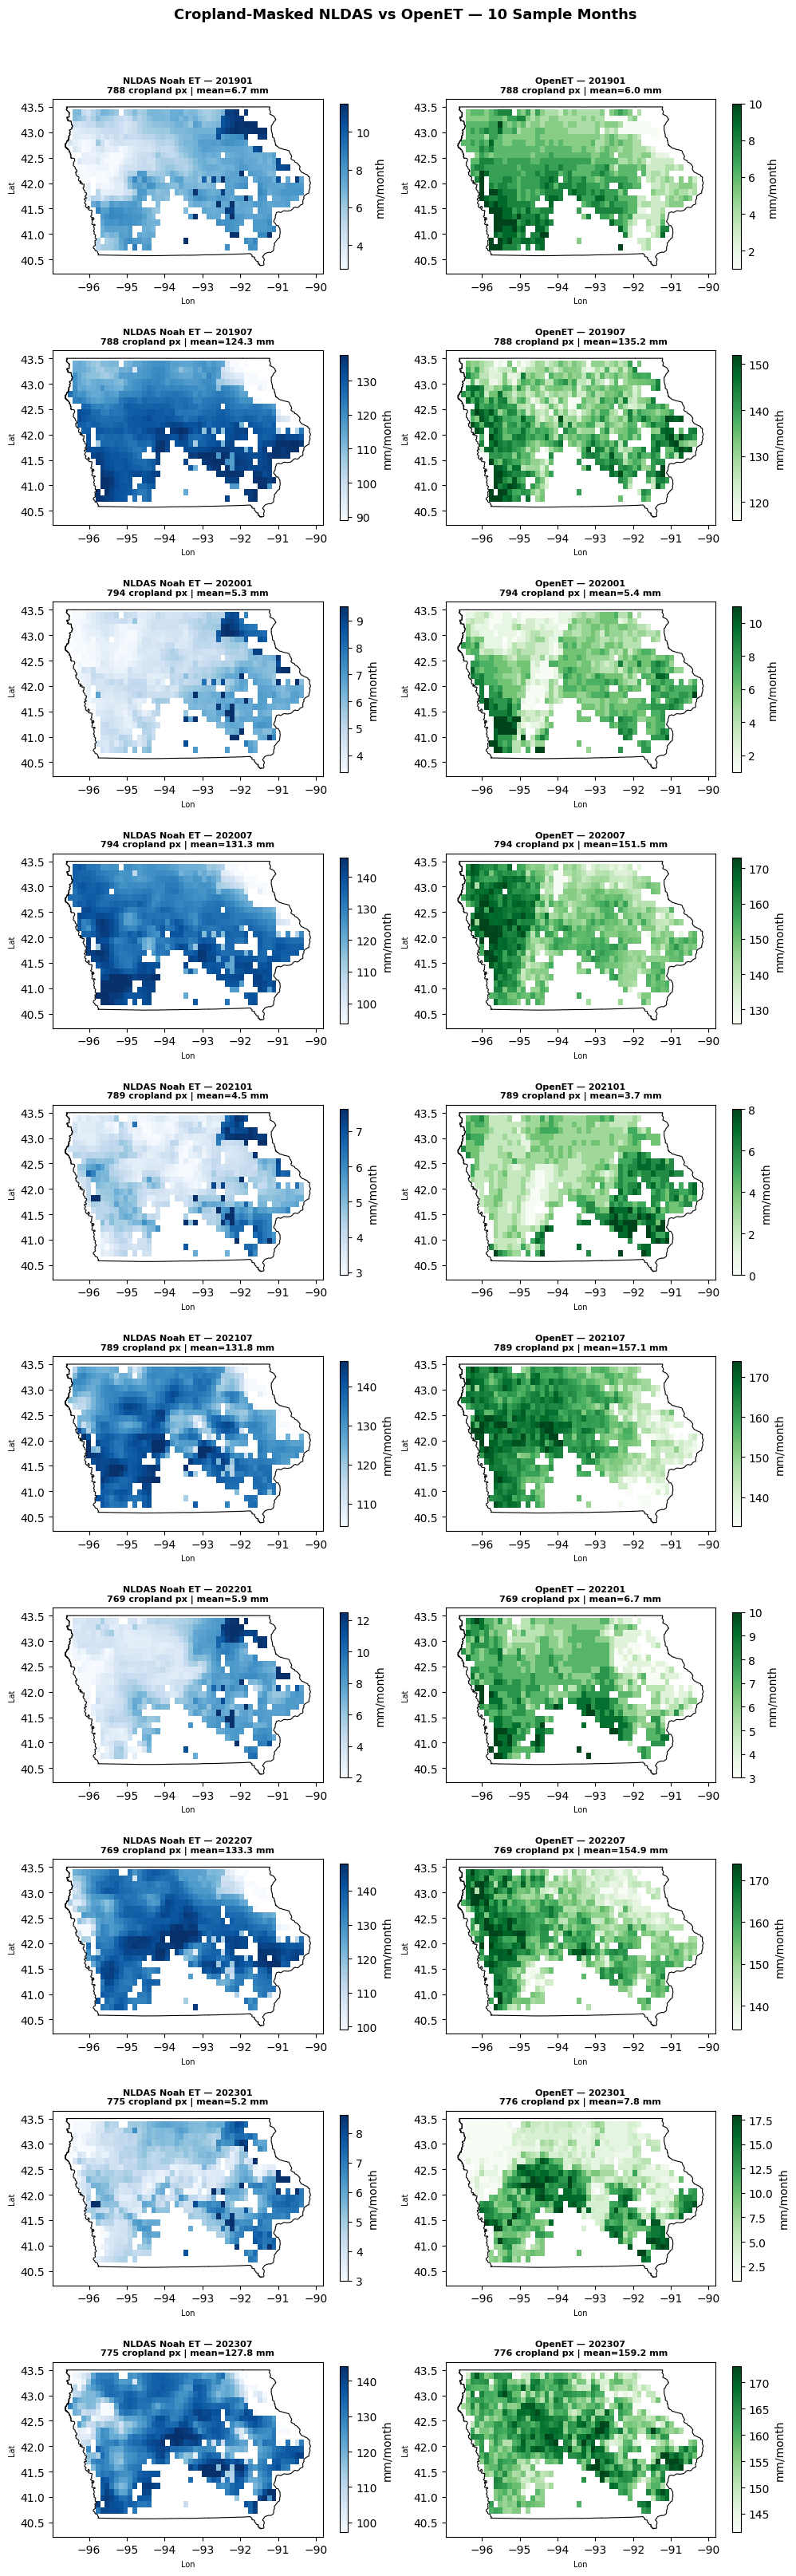

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/et_delta/masked_nldas_openet_diagnostic.png


In [10]:
# ── Side-by-side diagnostic: 10 sample months, NLDAS | OpenET ──────────────
step    = max(1, len(nldas_files) // 10)
samples = [f.name.split('.A')[1][:6] for f in nldas_files[::step][:10]]

ncols, nrows = 2, len(samples)
fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 3.2))

for row, yyyymm in enumerate(samples):
    year = int(yyyymm[:4])
    nldas_f  = nldas_masked_dir  / f'NLDAS_Iowa_cropland_{yyyymm}.tif'
    openet_f = openet_masked_dir / f'OpenET_Iowa_cropland_{yyyymm}.tif'

    for col, (fpath, label, cmap) in enumerate([
        (nldas_f,  'NLDAS Noah ET', 'Blues'),
        (openet_f, 'OpenET',        'Greens'),
    ]):
        ax = axes[row, col]
        if not fpath.exists():
            ax.set_title(f'{label} {yyyymm}\nFILE NOT FOUND', color='red')
            continue

        da = rxr.open_rasterio(fpath, masked=True).squeeze()
        arr = da.values.astype(float)

        valid = arr[~np.isnan(arr)]
        vmin, vmax_v = (np.nanpercentile(valid, [2, 98]) if len(valid) else (0, 1))
        if vmax_v - vmin < 1:
            vmin, vmax_v = max(0, vmin - 1), vmax_v + 1

        extent = [float(da.x.min()), float(da.x.max()),
                  float(da.y.min()), float(da.y.max())]
        im = ax.imshow(arr, extent=extent, origin='upper',
                       cmap=cmap, vmin=vmin, vmax=vmax_v, aspect='auto')
        iowa_gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
        plt.colorbar(im, ax=ax, shrink=0.8, label='mm/month')

        n_crop = int((~np.isnan(arr)).sum())
        ax.set_title(f'{label} — {yyyymm}\n{n_crop} cropland px | mean={np.nanmean(arr):.1f} mm',
                     fontsize=8, fontweight='bold')
        ax.set_xlabel('Lon', fontsize=7)
        ax.set_ylabel('Lat', fontsize=7)

plt.suptitle('Cropland-Masked NLDAS vs OpenET — 10 Sample Months',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
out_fig = figures_dir / 'masked_nldas_openet_diagnostic.png'
plt.savefig(out_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {out_fig}')


## 6. Save Summary CSV

In [11]:
csv_path = output_dir / 'ET_delta_monthly_summary_Iowa_cropland.csv'
df.to_csv(csv_path, index=False)
print(f'Saved: {csv_path}')
print(df.to_string(index=False))

Saved: /home/pielab-sandbox-jcoldiron/SIF-Analysis/data/processed/ET_delta/ET_delta_monthly_summary_Iowa_cropland.csv
 year  month yyyymm  n_crop_pixels  openet_mean  nldas_mean  delta_mean  delta_std  delta_min  delta_max
 2019      1 201901            788     6.000000    6.654387   -0.654387   3.297643 -11.854794   8.427500
 2019      2 201902            788     4.925127    7.515855   -2.590728   3.555949 -11.750807   7.149000
 2019      3 201903            788    22.782995   16.491104    6.291890   8.221419 -14.603296  29.819397
 2019      4 201904            788    44.526650   29.967361   14.559288   9.885582 -20.097988  77.328497
 2019      5 201905            788    58.931472   54.929718    4.001757  14.086570 -30.480782  52.444061
 2019      6 201906            788    94.434010   85.197540    9.236468  18.903678 -47.622169  80.963383
 2019      7 201907            788   135.233503  124.345665   10.887840  12.062340 -31.382736  80.699928
 2019      8 201908            788   109.2

## 7. Visualize — Time Series of Mean Delta (Cropland Only)

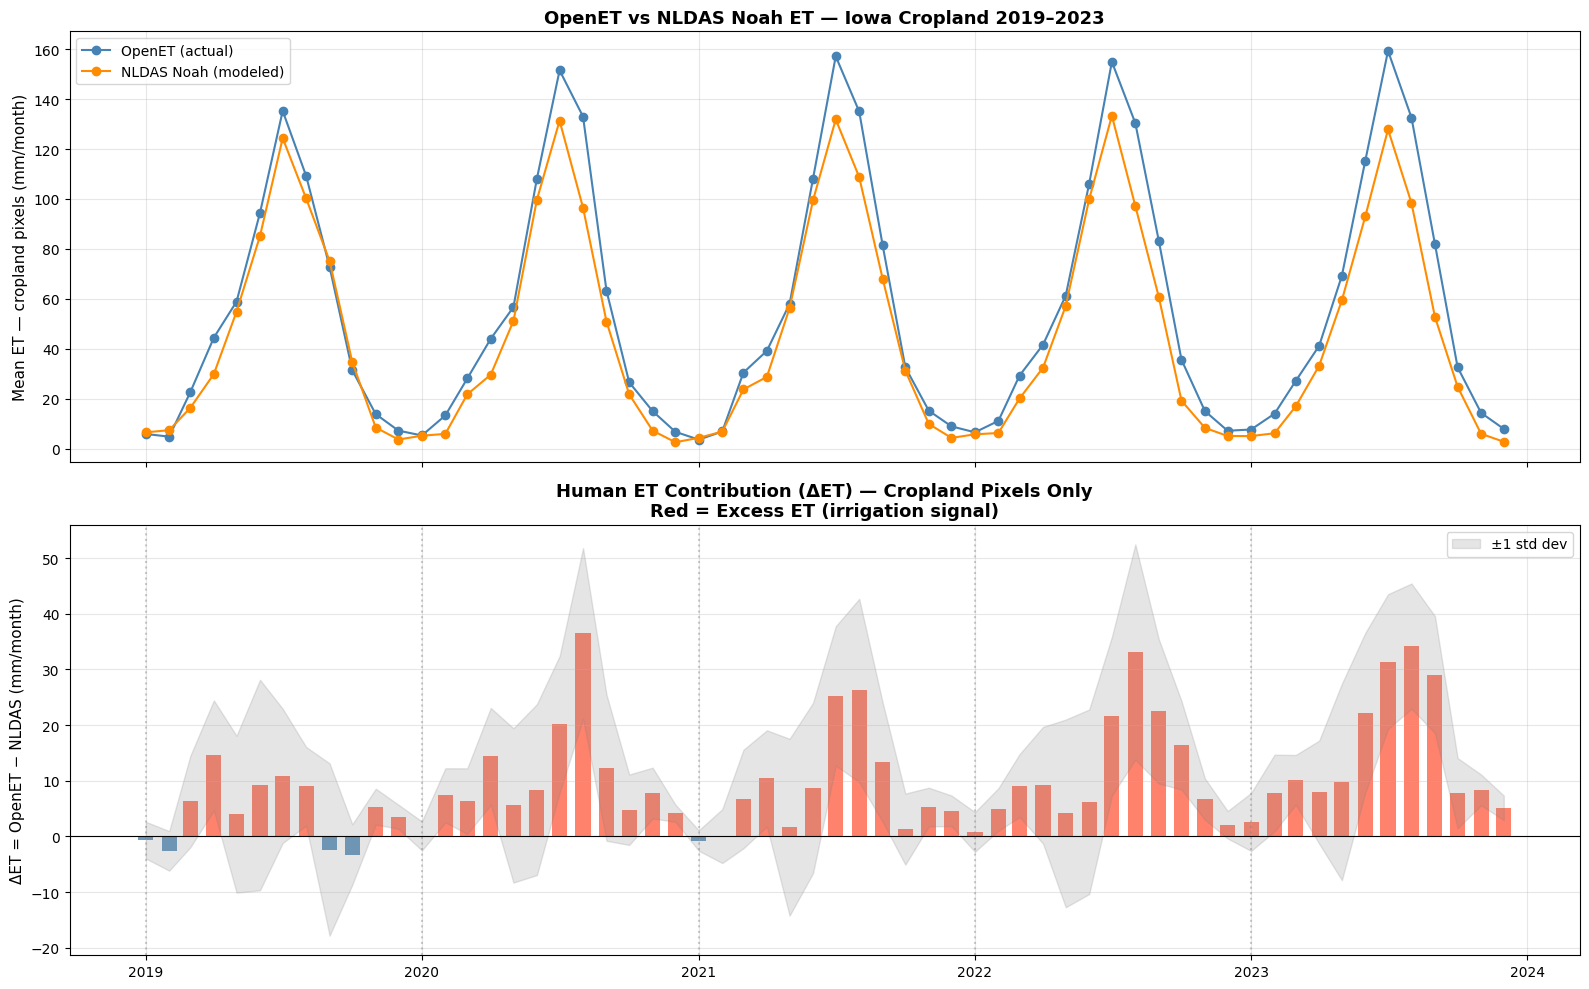

In [12]:
dates = pd.to_datetime(df['yyyymm'], format='%Y%m')

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top: OpenET vs NLDAS Noah
axes[0].plot(dates, df['openet_mean'], 'o-', color='steelblue', label='OpenET (actual)', linewidth=1.5)
axes[0].plot(dates, df['nldas_mean'],  'o-', color='darkorange', label='NLDAS Noah (modeled)', linewidth=1.5)
axes[0].set_ylabel('Mean ET — cropland pixels (mm/month)', fontsize=11)
axes[0].set_title('OpenET vs NLDAS Noah ET — Iowa Cropland 2019–2023', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bottom: Delta
bar_colors = ['tomato' if v > 0 else 'steelblue' for v in df['delta_mean']]
axes[1].bar(dates, df['delta_mean'], width=20, color=bar_colors, alpha=0.8)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].fill_between(dates,
    df['delta_mean'] - df['delta_std'],
    df['delta_mean'] + df['delta_std'],
    alpha=0.2, color='gray', label='±1 std dev')
axes[1].set_ylabel('ΔET = OpenET − NLDAS (mm/month)', fontsize=11)
axes[1].set_title('Human ET Contribution (ΔET) — Cropland Pixels Only\nRed = Excess ET (irrigation signal)',
                  fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for year in YEARS:
    axes[1].axvline(pd.Timestamp(f'{year}-01-01'), color='gray', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig(figures_dir / 'et_delta_timeseries_cropland.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Visualize — Seasonal Cycle of Delta

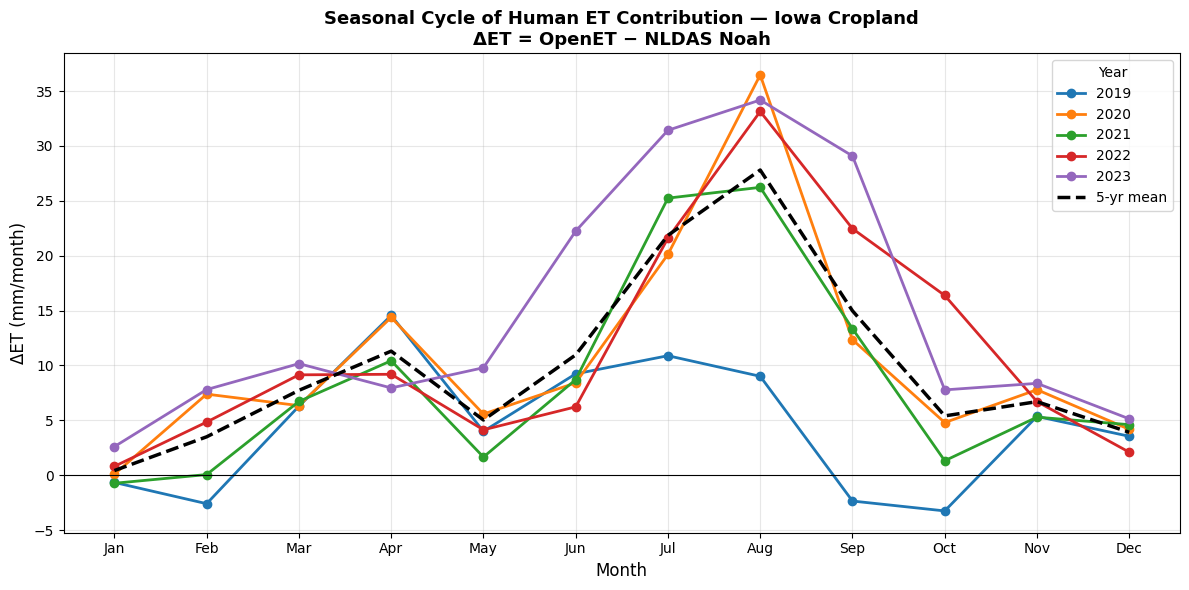

In [13]:
colors_yr = {2019: '#1f77b4', 2020: '#ff7f0e', 2021: '#2ca02c', 2022: '#d62728', 2023: '#9467bd'}

fig, ax = plt.subplots(figsize=(12, 6))

for year in YEARS:
    yr = df[df['year'] == year].sort_values('month')
    if not yr.empty:
        ax.plot(yr['month'], yr['delta_mean'], 'o-',
                color=colors_yr[year], linewidth=2, markersize=6, label=str(year))

monthly_mean = df.groupby('month')['delta_mean'].mean()
ax.plot(monthly_mean.index, monthly_mean.values, 'k--', linewidth=2.5, label='5-yr mean', zorder=5)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('ΔET (mm/month)', fontsize=12)
ax.set_title('Seasonal Cycle of Human ET Contribution — Iowa Cropland\nΔET = OpenET − NLDAS Noah',
             fontsize=13, fontweight='bold')
ax.legend(title='Year')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'et_delta_seasonal_cycle_cropland.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Visualize — Spatial Maps of Masked Delta

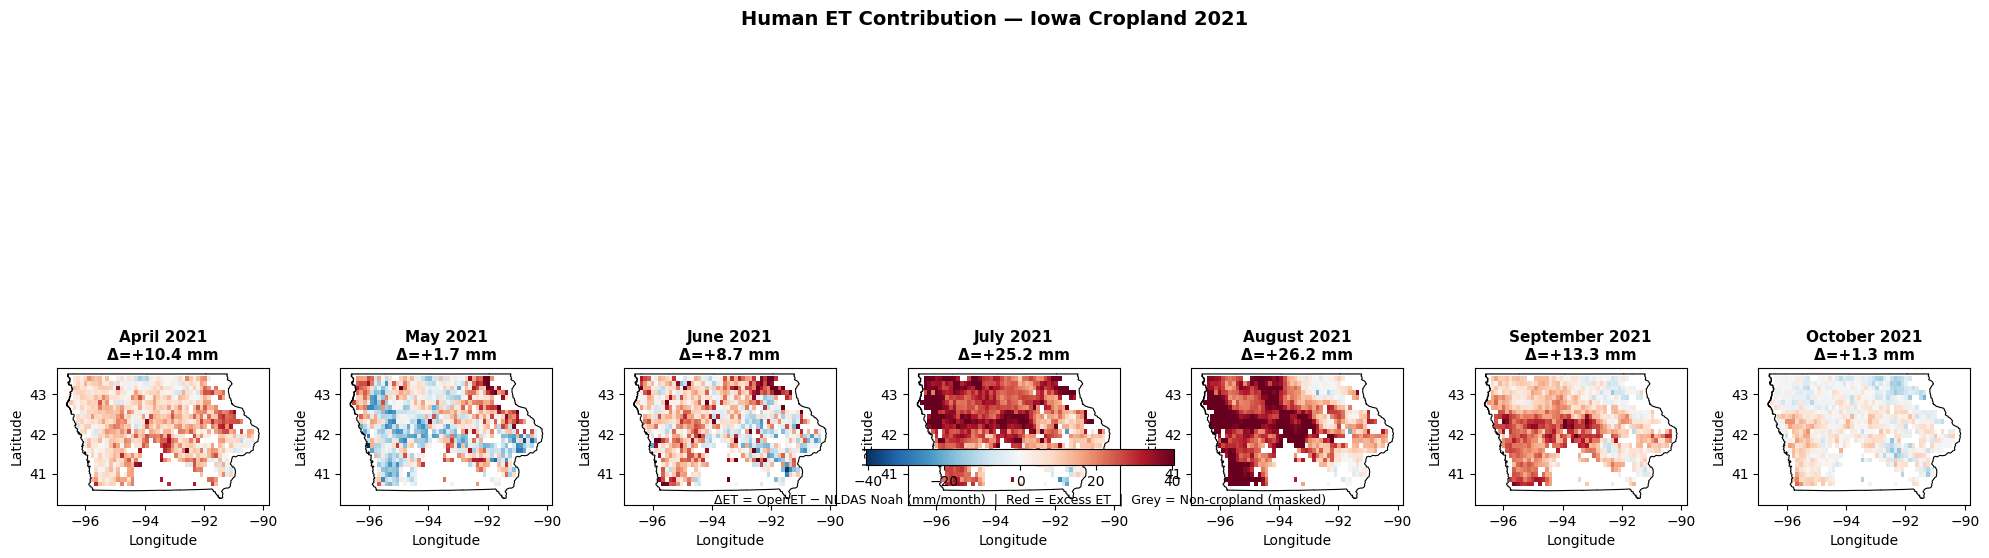

In [16]:
sample_year = 2021
plot_months = [4, 5, 6, 7, 8, 9, 10]
month_names = {4: 'April', 5:'May', 6:'June', 7:'July', 8:'August', 9:'September', 10:'October'}

fig, axes = plt.subplots(1, len(plot_months), figsize=(20, 5))

all_vals = np.concatenate([
    delta_grids[(sample_year, m)].values.flatten()
    for m in plot_months if (sample_year, m) in delta_grids
])
vmax = np.nanpercentile(np.abs(all_vals), 95)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

for ax, month in zip(axes, plot_months):
    if (sample_year, month) not in delta_grids:
        ax.set_visible(False)
        continue
    data = delta_grids[(sample_year, month)]
    im = ax.imshow(
        data.values,
        extent=[float(data.x.min()), float(data.x.max()),
                float(data.y.min()), float(data.y.max())],
        origin='upper', cmap='RdBu_r', norm=norm
    )
    iowa_gdf.boundary.plot(ax=ax, color='black', linewidth=0.8)
    mean_val = float(np.nanmean(data.values))
    ax.set_title(f'{month_names[month]} {sample_year}\nΔ={mean_val:+.1f} mm', fontsize=11, fontweight='bold')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')

cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.04, pad=0.15)
cbar.set_label('ΔET = OpenET − NLDAS Noah (mm/month)  |  Red = Excess ET  |  Grey = Non-cropland (masked)', fontsize=9)
plt.suptitle(f'Human ET Contribution — Iowa Cropland {sample_year}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(figures_dir / f'et_delta_maps_{sample_year}_cropland.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Annual Mean Delta Heatmap

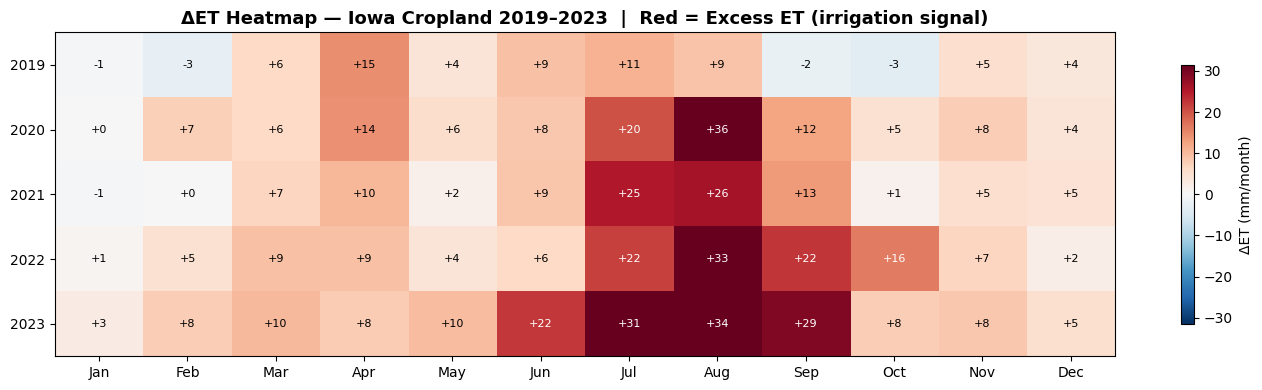

In [15]:
pivot = df.pivot(index='year', columns='month', values='delta_mean')

vmax = np.nanpercentile(np.abs(pivot.values[~np.isnan(pivot.values)]), 95)
norm = mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

fig, ax = plt.subplots(figsize=(14, 4))
im = ax.imshow(pivot.values, cmap='RdBu_r', norm=norm, aspect='auto')

ax.set_xticks(range(12))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)

for i in range(len(pivot.index)):
    for j in range(12):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:+.0f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(val) > vmax * 0.5 else 'black')

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('ΔET (mm/month)')
ax.set_title('ΔET Heatmap — Iowa Cropland 2019–2023  |  Red = Excess ET (irrigation signal)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(figures_dir / 'et_delta_heatmap_cropland.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Summary

In [21]:
month_names_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
                   7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

print('=' * 65)
print('ET Harmonization Summary — Iowa Cropland 2019–2023')
print('=' * 65)
print(f'Cropland fraction threshold: {CROPLAND_FRACTION_THRESHOLD}')
print(f'Months processed: {len(df)}')
print(f'Months skipped:   {len(skipped)}')
print()
print(f'Mean cropland pixels per month: {df["n_crop_pixels"].mean():.0f}')
print(f'Overall mean OpenET (cropland): {df["openet_mean"].mean():.1f} mm/month')
print(f'Overall mean NLDAS  (cropland): {df["nldas_mean"].mean():.1f} mm/month')
print(f'Overall mean ΔET    (cropland): {df["delta_mean"].mean():+.1f} mm/month')
print()
print('Annual mean ΔET (cropland pixels):')
for year, grp in df.groupby('year'):
    print(f'  {year}: {grp["delta_mean"].mean():+.1f} mm/month  '
          f'(annual sum: {grp["delta_mean"].sum():+.0f} mm/yr)')
print()
print('Peak months (highest mean ΔET):')
top = df.groupby('month')['delta_mean'].mean().sort_values(ascending=False).head(4)
for m, v in top.items():
    print(f'  {month_names_map[m]}: {v:+.1f} mm/month')
print()
print(f'Output GeoTIFFs: {output_dir}')
print(f'Summary CSV:     {csv_path}')
print(f'Figures:         {figures_dir}')

ET Harmonization Summary — Iowa Cropland 2019–2023
Cropland fraction threshold: 0.5
Months processed: 60
Months skipped:   0

Mean cropland pixels per month: 783
Overall mean OpenET (cropland): 55.3 mm/month
Overall mean NLDAS  (cropland): 45.3 mm/month
Overall mean ΔET    (cropland): +10.0 mm/month

Annual mean ΔET (cropland pixels):
  2019: +4.5 mm/month  (annual sum: +54 mm/yr)
  2020: +10.7 mm/month  (annual sum: +128 mm/yr)
  2021: +8.6 mm/month  (annual sum: +103 mm/yr)
  2022: +11.4 mm/month  (annual sum: +137 mm/yr)
  2023: +14.7 mm/month  (annual sum: +177 mm/yr)

Peak months (highest mean ΔET):
  Aug: +27.8 mm/month
  Jul: +21.9 mm/month
  Sep: +15.0 mm/month
  Apr: +11.3 mm/month

Output GeoTIFFs: /home/pielab-sandbox-jcoldiron/SIF-Analysis/data/processed/ET_delta
Summary CSV:     /home/pielab-sandbox-jcoldiron/SIF-Analysis/data/processed/ET_delta/ET_delta_monthly_summary_Iowa_cropland.csv
Figures:         /home/pielab-sandbox-jcoldiron/SIF-Analysis/figures/et_delta
